## Figure 4

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/fig4_bcp/`, `out/fig4_nofb/`, `out/fig4_nohl/`: BCP, No FB and No HL networks, 5 seeds each
- `out/fig4_example/`: BCP network with recorded activity (panels b-f, j)
- `out/fig4_example_nofb/`, `out/fig4_example_nohl/`: control networks with recorded output (panel k insets)

In [26]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

from pathlib import Path

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
from sklearn.linear_model import LinearRegression
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})

from bcp.analysis import HydraRunOutput, HydraMultirun, rebuild_traj_run
from bcp.utils.plotting import add_scalebar

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())


def relu(x):
    return np.maximum(x, 0)

#### Directory setup

In [27]:
out_dir = repo_root / "out"
shapes_dir = repo_root / "data" / "shapes"

fig4_dir = repo_root / "figures" / "fig4"
fig4_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [28]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_openloop = 'gray'
color_closedloop = '#F49F1E'
color_target = 'black'
color_accent = 'black'

linewidth = 1.0

cmap = cmc.cmaps['vikO']
cmap_exc = mpl.colors.LinearSegmentedColormap.from_list("", ["white", color_exc])
cmap_inh = mpl.colors.LinearSegmentedColormap.from_list("", ["white", color_inh])

SEED = 123

### Load example network

In [29]:
example_run = HydraRunOutput(out_dir / "fig4_example")
example_results = example_run.load_pickle('results.pkl')
cfg, task, vectorfield = rebuild_traj_run(example_run, shapes_dir)
inputs, target = task.inputs, task.target
alpha = cfg.model.alpha

X_TRAINING = example_results['training_time']
X_ITER = np.arange(0, cfg.T, cfg.dt)

/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg


### Panel a: example inputs

In [30]:
figsize_inputs = (4.15*cm, 5.1*cm)
nb_example_inputs = 6
input_extra = 0.5  # extra time simulated beyond one trajectory

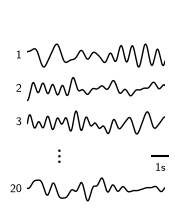

In [31]:
_ = inputs.simulate(cfg.T * (1 - input_extra / 2))
x = inputs.simulate(cfg.T * (1 + input_extra))
X_INPUTS = np.arange(0, cfg.T * (1 + input_extra), cfg.dt) - (input_extra / 2) * cfg.T
input_indices = np.random.default_rng(SEED).choice(x.shape[1], nb_example_inputs, replace=False)

fig = MultiPanel(grid=[1] * nb_example_inputs, figsize=figsize_inputs)
for panel, idx in enumerate(input_indices):
    ax = fig.panels[panel]
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(False)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlim([X_INPUTS[0], X_INPUTS[-1]])

    if panel == 0:
        ax.set_ylim([-1, 1])
    elif panel != nb_example_inputs - 2:
        ax.plot(X_INPUTS, x[:, idx], color='black', linewidth=linewidth)
        input_idx = panel if panel < nb_example_inputs - 2 else x.shape[1]
        ax.set_ylabel(rf'{input_idx}', fontsize=8, color='black', rotation=0,
                      labelpad=4, ha='right', va='center')
    else:
        add_scalebar(ax, matchx=False, matchy=False, sizex=1.0, sizey=0.0,
                     labelx='1s', labely='0.0', loc='lower right', barwidth=1.5, pad=-0.5, sep=5)
        ax.text(0.5, 0.5, r'$\vdots$', fontsize=20, color='black', ha='center', va='center')

plt.savefig(fig4_dir / 'a_inputs.pdf', bbox_inches='tight')
plt.show()

### Panel b: target and output before learning, target shape

In [32]:
size_output = (4.0*cm, 2.8*cm)
size_shape = (4.0*cm, 2.5*cm)

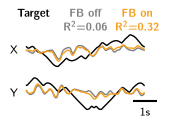

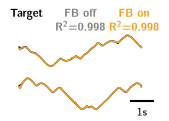

In [33]:
def plot_output(rec_idx, r2_fmt, filename, hide_spines):
    R2_OL = float(example_results['OL_R2'][rec_idx])
    R2_CL = float(example_results['CL_R2'][rec_idx])
    labels = [
        (r"$\textbf{Target}$", color_target),
        (rf"$\begin{{array}}{{c}} \textbf{{FB off}} \\ \textbf{{{{\boldmath$R^2$}}={R2_OL:{r2_fmt}}}} \end{{array}}$", color_openloop),
        (rf"$\begin{{array}}{{c}} \textbf{{FB on}} \\ \textbf{{{{\boldmath$R^2$}}={R2_CL:{r2_fmt}}}} \end{{array}}$", color_closedloop),
    ]

    fig = MultiPanel(grid=[1, 1], figsize=size_output, sharey=True, sharex=True, hspace=0.1, wspace=0.1)
    for dim, ax in enumerate(fig.panels):
        ax.plot(X_ITER, target.get_trajectory()[:, dim], color=color_target, lw=linewidth)
        ax.plot(X_ITER, example_results['OL_uOut'][rec_idx, :, dim], color=color_openloop, lw=linewidth)
        ax.plot(X_ITER, example_results['CL_uOut'][rec_idx, :, dim], color=color_closedloop, lw=linewidth)
        if hide_spines:
            for side in ['top', 'right', 'bottom', 'left']:
                ax.spines[side].set_visible(False)
            ax.set_yticks([])
            ax.set_xticks([])
        else:
            ax.axis('off')

    add_scalebar(fig.panels[1], matchx=False, matchy=False, hidex=False, hidey=False,
                 sizex=1.0, sizey=0.0, labelx='1s', labely='0.0',
                 loc='lower right', barwidth=1.5, pad=-0.7, sep=5)
    for xpos, (text, color) in zip([0.1, 0.5, 0.9], labels):
        fig.panels[0].text(xpos, 1.7, text, transform=fig.panels[0].transAxes,
                           ha='center', va='top', color=color, fontsize=8)
    if hide_spines:
        fig.panels[0].set_ylabel(r'X', fontsize=8, color='black', rotation=0, labelpad=2, ha='right', va='center')
        fig.panels[1].set_ylabel(r'Y', fontsize=8, color='black', rotation=0, labelpad=2, ha='right', va='center')

    plt.savefig(fig4_dir / filename, bbox_inches='tight')
    plt.show()


plot_output(0, '.2f', 'b_output.pdf', hide_spines=True)
plot_output(-1, '.3f', 'NA_b_output_after.pdf', hide_spines=False)

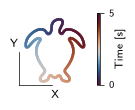

In [34]:
fig, ax = plt.subplots(1, 1, figsize=size_shape)

trajectory = target.get_trajectory()
points = trajectory.reshape(-1, 1, 2)
segments = np.concatenate([points[:-3], points[3:]], axis=1)
norm = plt.Normalize(0, cfg.T)
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(np.linspace(0, cfg.T, len(trajectory)))
lc.set_linewidth(linewidth * 1.75)
ax.add_collection(lc)
ax.autoscale_view()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'Time [s]', labelpad=0)
cbar.set_ticks([0, cfg.T])
cbar.set_ticklabels([0, cfg.T])

ax.set_aspect('equal', adjustable='box', anchor='SE')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(-1.1, -0.1)
ax.spines['bottom'].set_bounds(-1.1, -0.1)
ax.set_ylim([-1.1, 1.1])
ax.set_xlim([-1.1, 1.1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('X')
ax.set_ylabel('Y', rotation=0)

plt.savefig(fig4_dir / 'b_shape.pdf', bbox_inches='tight')
plt.show()

### Panel c: E/I balance without and with feedback, before learning

In [35]:
t_start = 3000  # average over the last 2 s of the first trajectory
size_EIplot = (4.8*cm, 2.6*cm)

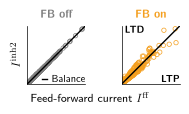

In [36]:
I_E = alpha * relu(example_results['I_FF_bar'][0, t_start:]).mean(0)
I_I = example_results['OL_I_IE'][0, t_start:].mean(0)
I_I_CL = example_results['CL_I_IE'][0, t_start:].mean(0)

fig = MultiPanel(grid=[2], figsize=size_EIplot, hspace=0.0, wspace=0.0)
for ax in fig.panels:
    ax.set_yticks([])
    ax.set_xticks([])

fig.panels[0].scatter(I_E, I_I, s=10, marker='o', facecolors='none', edgecolors=color_openloop)
fig.panels[1].scatter(I_E, I_I_CL, s=10, marker='o', facecolors='none', edgecolors=color_closedloop)
fig.panels[0].plot([0, 1], [0, 1], color=color_accent, lw=linewidth, label='Balance')
fig.panels[1].plot([0, 1], [0, 1], color=color_accent, lw=linewidth)

fig.panels[0].set_ylabel(r'$I^{\mathrm{inh2}}$', fontsize=8)
fig.fig.supxlabel(r'Feed-forward current $I^{\mathrm{ff}}$', fontsize=8)
for ax, I in zip(fig.panels, [I_I, I_I_CL]):
    lim = 1.05 * np.max([I_E, I])
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect('equal', adjustable='box', anchor='SE')

fig.panels[0].set_title(r'\textbf{FB off}', fontsize=8, color=color_openloop)
fig.panels[1].set_title(r'\textbf{FB on}', fontsize=8, color=color_closedloop)
fig.panels[1].text(0.05, 1.0, r'\textbf{LTD}', fontsize=7, color=color_accent, ha='left', va='top', transform=fig.panels[1].transAxes)
fig.panels[1].text(1.0, 0.0, r'\textbf{LTP}', fontsize=7, color=color_accent, ha='right', va='bottom', transform=fig.panels[1].transAxes)
fig.panels[0].legend(loc='lower right', fontsize=7, frameon=False, handlelength=0.5, handletextpad=0.5,
                     borderpad=-0.5, labelspacing=0.5)

plt.savefig(fig4_dir / 'c_ei_balance.pdf', bbox_inches='tight')
plt.show()

### Panel d: hidden layer activity before learning

In [37]:
figsize_hidden_act = (4*cm, 2.6*cm)

/var/folders/hv/pkkqx_mx7s12wnhdkf46t2qr0000gn/T/ipykernel_58981/973329029.py:6: RuntimeWarning: invalid value encountered in divide
  ax.imshow(rE / rE.max(axis=0), cmap=cmap_exc, aspect='auto', origin='upper',


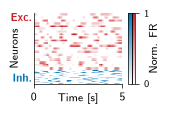

In [38]:
rE = example_results['OL_rE'][0].T
rI = example_results['OL_rI'][0].T
nE, nI = rE.shape[0], rI.shape[0]

fig, ax = plt.subplots(figsize=figsize_hidden_act)
ax.imshow(rE / rE.max(axis=0), cmap=cmap_exc, aspect='auto', origin='upper',
          extent=[0, cfg.T, nE + nI, nI], vmin=0, vmax=1, interpolation='none')
ax.imshow(rI / rI.max(axis=0), cmap=cmap_inh, aspect='auto', origin='upper',
          extent=[0, cfg.T, nI, 0], vmin=0, vmax=1, interpolation='none')

ax.set_ylim(0, nE + nI)
ax.set_yticks([])
ax.text(-0.1, nE + nI, r'\textbf{Exc.}', ha='right', va='top', fontsize=8, color=color_exc)
ax.text(-0.1, 0, r'\textbf{Inh.}', ha='right', va='bottom', fontsize=8, color=color_inh)
ax.set_xlabel('Time [s]', fontsize=8, labelpad=-7)
ax.set_xticks([0, cfg.T])
ax.set_xticklabels([0, 5], fontsize=8)
ax.set_ylabel('Neurons', fontsize=8, labelpad=10)
ax.set_xlim(0, cfg.T)

cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_exc), ax=ax, orientation='vertical', ticks=[0, 1], pad=0.0, aspect=20)
cbar2 = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_inh), ax=ax, orientation='vertical', ticks=[0, 1], pad=0.03, aspect=20)
cbar2.set_ticks([])
cbar.set_ticks([0, 1])
cbar.set_ticklabels([0, 1])
cbar.set_label('Norm. FR', fontsize=8, labelpad=0)

plt.savefig(fig4_dir / 'd_hidden_activity.pdf', bbox_inches='tight')
plt.show()

### Panel e: balance error vs. firing rate

In [39]:
sample_length = 500  # 0.5 s windows
N_samples_per_neuron = 10
figsize_error = (2.6*cm, 2.6*cm)

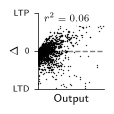

In [40]:
error = alpha * relu(example_results['I_FF_bar'][0]) - example_results['CL_I_IE'][0]
CL_rE = example_results['CL_rE'][0]

rng = np.random.default_rng(SEED)
starts = rng.integers(0, CL_rE.shape[0] - sample_length, size=(CL_rE.shape[1], N_samples_per_neuron))
samples_rE = np.array([CL_rE[s:s + sample_length, n].mean() for n in range(CL_rE.shape[1]) for s in starts[n]])
samples_error = np.array([error[s:s + sample_length, n].mean() for n in range(CL_rE.shape[1]) for s in starts[n]])

reg = LinearRegression().fit(samples_rE.reshape(-1, 1), samples_error)
r2 = reg.score(samples_rE.reshape(-1, 1), samples_error)

fig, ax = plt.subplots(figsize=figsize_error)
ax.scatter(samples_rE, samples_error, color='black', s=1, marker='o', alpha=0.8, lw=0)
ax.text(0.05, 0.1, rf'$r^2={r2:.2f}$', fontsize=7, color='black', ha='left', va='top',
        bbox=dict(facecolor='white', edgecolor='white', pad=1))

ax.set_xlim(0, 0.6)
ax.set_ylim(-0.1, 0.1)
ax.set_xticks([])
ax.set_yticks([-0.1, 0, 0.1])
ax.set_yticklabels([r'LTD', '0', r'LTP'], fontsize=6)
ax.axhline(0, color='gray', lw=1, zorder=-1, ls='--')
ax.set_xlabel('Output', fontsize=8)
ax.set_ylabel(r'$\Delta$', fontsize=8, labelpad=-5)

plt.savefig(fig4_dir / 'e_error_vs_rate.pdf', bbox_inches='tight')
plt.show()

### Panel f: feed-forward weights during learning

In [41]:
nb_example_weights = 30
figsize_weights = (5.4*cm, 2.6*cm)

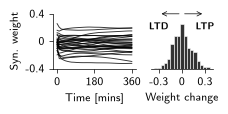

In [42]:
W_FF = example_results['W_FF'].reshape(example_results['W_FF'].shape[0], -1)  # [recordings, synapses]
idx = np.random.default_rng(SEED + 2).choice(W_FF.shape[1], nb_example_weights, replace=False)
delta_weights = W_FF[-1] - W_FF[0]

fig = MultiPanel(grid=[2], figsize=figsize_weights, hspace=0.0, wspace=0.0, width_ratios=[4, 3])

ax = fig.panels[0]
ax.plot(X_TRAINING, W_FF[:, idx], color='black', lw=linewidth / 1.5, alpha=0.8)
ax.set_xlabel('Time [mins]', fontsize=8)
ax.set_xticks([0, 180, 360])
ax.set_xticklabels([0, 180, 360], fontsize=8)
ax.set_ylabel(r'Syn. weight', fontsize=8)
ax.set_ylim(-0.4, 0.4)
ax.set_yticks([-0.4, 0, 0.4])
ax.set_yticklabels([-0.4, 0, 0.4], fontsize=8)

ax2 = fig.panels[1]
ax2.hist(delta_weights, bins=19, color='black', alpha=0.8, density=True)
ax2.annotate('', xy=(0.0, 5), xytext=(-0.3, 5), arrowprops=dict(arrowstyle='<-', color='black'))
ax2.annotate('', xy=(0.0, 5), xytext=(0.3, 5), arrowprops=dict(arrowstyle='<-', color='black'))
ax2.text(-0.3, 4.2, r'\textbf{LTD}', fontsize=7, color='black', ha='center', va='top')
ax2.text(0.3, 4.2, r'\textbf{LTP}', fontsize=7, color='black', ha='center', va='top')
ax2.set_xlabel(r'Weight change', fontsize=8)
ax2.set_yticks([])
ax2.set_xlim(-0.4, 0.4)
ax2.set_xticks([-0.3, 0, 0.3])
ax2.set_xticklabels([-0.3, 0, 0.3], fontsize=8)
ax2.set_ylim(0, 5)
ax2.spines['left'].set_visible(False)

plt.savefig(fig4_dir / 'f_weights.pdf', bbox_inches='tight')
plt.show()

### Panel j: output after 30 min and 6 h of training

In [43]:
plot_timepoints = [30, 360]  # min
size_traj_after = (3*cm, 2.6*cm)

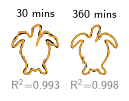

In [44]:
iter_idx = [np.argwhere(X_TRAINING == t).item() for t in plot_timepoints]
fig = MultiPanel(grid=[2], figsize=size_traj_after, hspace=0.0, wspace=0.0)

for ax, i, t in zip(fig.panels, iter_idx, plot_timepoints):
    OL_out = example_results['OL_uOut'][i]
    CL_out = example_results['CL_uOut'][i]
    ax.plot(OL_out[:, 0], OL_out[:, 1], color=color_openloop, lw=linewidth)
    ax.plot(CL_out[:, 0], CL_out[:, 1], color=color_closedloop, lw=linewidth)
    ax.plot(target.get_trajectory()[:, 0], target.get_trajectory()[:, 1], color=color_target, lw=linewidth, zorder=-1)
    ax.axis('off')
    ax.set_aspect('equal', adjustable='box', anchor='SE')
    ax.text(0.5, 1.05, rf'{t} mins', fontsize=8, color='black', ha='center', va='bottom', transform=ax.transAxes)
    ax.text(0.5, -0.05, rf"$R^2$={example_results['OL_R2'][i]:.3f}",
            fontsize=8, color=color_openloop, ha='center', va='top', transform=ax.transAxes)

plt.savefig(fig4_dir / 'j_trajectories.pdf', bbox_inches='tight')
plt.show()

### Panels g-i: training performance

In [45]:
figsize_perf = (10*cm, 2.6*cm)
xticks_time = [0, 180, 360]

In [46]:
tables = {}
for name in ['bcp', 'nofb', 'nohl']:
    tables[name] = HydraMultirun(out_dir / f"fig4_{name}", result_files=['results.pkl']).table(
        keys=['OL_R2', 'OL_loss'] + (['CL_error', 'training_time'] if name == 'bcp' else []))

R2 = np.stack(tables['bcp']['OL_R2'])
LOSS = np.stack(tables['bcp']['OL_loss'])
FB = np.abs(np.stack(tables['bcp']['CL_error'])).mean(-1)
X_RUNS = tables['bcp']['training_time'][0]

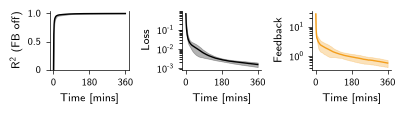

In [47]:
fig = MultiPanel(grid=[3], figsize=figsize_perf, width_ratios=[1, 1, 1])

for ax, data, color in zip(fig.panels, [R2, LOSS, FB], ['black', 'black', color_closedloop]):
    ax.plot(X_RUNS, data.mean(0), color=color, lw=linewidth)
    ax.fill_between(X_RUNS, data.mean(0) - data.std(0), data.mean(0) + data.std(0), color=color, alpha=0.3)
    ax.set_xlabel('Time [mins]')
    ax.set_xticks(xticks_time)
    ax.set_xticklabels(xticks_time)

ax = fig.panels[0]
ax.set_ylim(1e-1, 1.05)
ax.spines['right'].set_visible(True)
ax.set_ylabel(r'$R^2$ (FB off)', fontsize=8)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels([0, 0.5, 1.0])

ax = fig.panels[1]
ax.set_ylabel(r'Loss', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e-3, 1e-2, 1e-1])
ax.set_yticklabels([r'10\textsuperscript{-3}', r'10\textsuperscript{-2}', r'10\textsuperscript{-1}'])

ax = fig.panels[2]
ax.set_ylabel(r'Feedback', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e0, 1e1])
ax.set_yticklabels([r'10\textsuperscript{0}', r'10\textsuperscript{1}'])

plt.savefig(fig4_dir / 'g-i_performance.pdf', bbox_inches='tight')
plt.show()

### Panel k: BCP vs. no feedback vs. no hidden layer

In [48]:
figsize_comparison = (3.1*cm, 2.2*cm)
figsize_insets = (2*cm, 1*cm)

bcp: final R2 0.997 +- 0.001
nofb: final R2 0.417 +- 0.075
nohl: final R2 0.531 +- 0.023


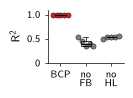

In [49]:
final_R2 = {name: np.stack(t['OL_R2'])[:, -1] for name, t in tables.items()}
for name, v in final_R2.items():
    print(f"{name}: final R2 {v.mean():.3f} +- {v.std():.3f}")


def swarm_box_plot(data_list, labels, figsize, colors, box_width=0.4, box_alpha=0.3,
                   jitter_x=0.6, point_size=14, point_alpha=1.0, ylabel=None, yticks=None):
    # also sets the rcParams used by all later panels
    plt.rcParams.update({
        'font.size': 8,
        'axes.linewidth': 0.5,
        'axes.labelsize': 8,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.major.size': 2,
        'ytick.major.size': 2,
        'lines.linewidth': 0.75,
    })
    fig, ax = plt.subplots(figsize=figsize)
    positions = np.arange(len(data_list))

    for pos, data, color in zip(positions, data_list, colors):
        ax.boxplot([data], positions=[pos], widths=box_width, patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=to_rgba(color, box_alpha), edgecolor='black', linewidth=0.5),
                   whiskerprops=dict(linewidth=0.5, color='black'),
                   medianprops=dict(linewidth=0.75, color='black'),
                   capprops=dict(linewidth=0.5, color='black'))
        x_jittered = np.linspace(pos - jitter_x / 2, pos + jitter_x / 2, len(data))
        ax.scatter(x_jittered, data, s=point_size, color=color, alpha=point_alpha,
                   edgecolor='black', linewidth=0.3)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(y) for y in yticks])
    return fig, ax


fig, ax = swarm_box_plot(
    [final_R2['bcp'], final_R2['nofb'], final_R2['nohl']],
    ['BCP', 'no\nFB', 'no\nHL'],
    figsize=figsize_comparison,
    colors=[color_exc, 'gray', 'gray'],
    ylabel=r'$R^2$',
    yticks=[0, 0.5, 1.0],
)
ax.set_ylim(0, 1.1)

plt.savefig(fig4_dir / 'k_r2_comparison.pdf', bbox_inches='tight')
plt.show()

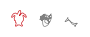

In [50]:
insets = [
    (example_results['OL_uOut'][-1], color_exc),
    (HydraRunOutput(out_dir / "fig4_example_nofb").load_pickle('results.pkl')['OL_uOut'][-1], 'gray'),
    (HydraRunOutput(out_dir / "fig4_example_nohl").load_pickle('results.pkl')['OL_u'][-1], 'gray'),
]

fig = MultiPanel(grid=[3], figsize=figsize_insets, hspace=0.0, wspace=0.0)
for ax, (out, color) in zip(fig.panels, insets):
    ax.axis('off')
    ax.set_aspect('equal', adjustable='box', anchor='SE')
    ax.set_xlim(-1.1, 1.1)
    ax.plot(out[:, 0], out[:, 1], color=color, lw=linewidth / 2)

plt.savefig(fig4_dir / 'k_insets.pdf', bbox_inches='tight')
plt.show()